# ToS Shield – EDA: `lex_glue / unfair_tos`

**Step 1 of the ML pipeline** — Before we fine-tune DistilBERT, we need to understand the data.

### Objectives
1. Load and inspect the `lex_glue/unfair_tos` dataset
2. Audit class distribution and **imbalance** (the dataset is ~69% "Fair")
3. Analyse text-length characteristics per class
4. N-gram vocabulary analysis (fair vs unfair)
5. Compare resampling strategies and **justify our choice** (downsample 2:1)
6. Export balanced train split ready for Step 2

### Project Structure
```
tos_shield/
├── notebooks/
│   └── 01_eda_unfair_tos.ipynb   # YOU ARE HERE
├── src/
│   ├── __init__.py
│   ├── data_loader.py            # HF loader + mock fallback
│   ├── eda_utils.py              # all plot/stat helpers
│   └── imbalance.py              # imbalance analysis & resampling
└── outputs/                      # generated artefacts
```


## 1. Environment Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # adds project root so src/ is importable

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
matplotlib.rcParams["figure.dpi"] = 110

print(f"Python     : {sys.version.split()[0]}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")
print(f"Matplotlib : {matplotlib.__version__}")

Python     : 3.12.10
NumPy      : 2.2.6
Pandas     : 2.2.3
Matplotlib : 3.10.8


## 2. Import from `src/`

> All project logic lives in the `src/` package. The notebook only orchestrates.

In [2]:
from src import (
    # ── Dataset ─────────────────────────────────────────────────────────
    load_dataset,
    LABEL_NAMES, LABEL_ABBR, UNFAIR_LABELS, FAIR_LABEL,
    DatasetSplit,
    # ── EDA helpers ──────────────────────────────────────────────────────
    set_style,
    compute_class_stats, compute_imbalance_ratio, compute_text_stats,
    downsample_majority_class, get_top_ngrams,
    plot_class_distribution, plot_unfair_breakdown,
    plot_text_length_distribution, plot_text_stats_heatmap,
    plot_sample_balance_splits, plot_top_ngrams,
    PALETTE_FAIR, PALETTE_UNFAIR,
    # ── Imbalance ────────────────────────────────────────────────────────
    imbalance_report, plot_imbalance_summary,
    compute_class_weights_sklearn, effective_number_of_samples,
    simulate_resampling,
)

print("All imports successful")

All imports successful


## 3. Load Dataset

Tries HuggingFace `datasets` first. If the network is unavailable (e.g. offline CI),
falls back to a **deterministic mock corpus** with the exact same schema and realistic class frequencies.


In [3]:
from datasets import load_dataset as hf_load

In [4]:
# src/data_loader.py → load_dataset()
splits = load_dataset(use_mock_fallback=False, seed=42, verbose=True)

train_df = splits["train"].df
val_df   = splits["validation"].df
test_df  = splits["test"].df

print(f"\nColumns : {list(train_df.columns)}")
train_df.head(4)

📦 Loading lex_glue / unfair_tos from HuggingFace …
 train        → 5,532 samples
 validation   → 2,275 samples
 test         → 1,607 samples

Columns : ['text', 'label', 'label_name', 'label_abbr', 'is_unfair', 'text_length', 'word_count', 'sentence_count']


,text,label,label_name,label_abbr,is_unfair,text_length,word_count,sentence_count
0,notice to california subscribers : you may can...,9,OK / Fair,OB,0,195,33,2
1,"if you subscribed using your apple id , refund...",9,OK / Fair,OB,0,85,17,2
2,"if you wish to request a refund , please visit...",9,OK / Fair,OB,0,79,12,4
3,if you subscribed using your google play store...,9,OK / Fair,OB,0,108,17,1


## 4. Label Schema

Labels **0–8** are *unfair* clause types. Label **9** is the *fair/OK* baseline.
This schema comes from the [lex_glue paper](https://arxiv.org/abs/2110.00976).


In [5]:
label_schema = pd.DataFrame([
    {"ID": k, "Abbreviation": v, "Full Name": LABEL_NAMES[k],
     "Type": "⚠️ Unfair" if k in UNFAIR_LABELS else "✅ Fair"}
    for k, v in LABEL_ABBR.items()
])
label_schema

,ID,Abbreviation,Full Name,Type
0,0,a,Arbitration,⚠️ Unfair
1,1,ch,Content Removal,⚠️ Unfair
2,2,cr,Copyright/IP,⚠️ Unfair
3,3,j,Jurisdiction,⚠️ Unfair
4,4,law,Governing Law,⚠️ Unfair
5,5,ltd,Limitation of Liability,⚠️ Unfair
6,6,ter,Unilateral Termination,⚠️ Unfair
7,7,use,Broad Data Use,⚠️ Unfair
8,8,pinc,Privacy Change,⚠️ Unfair
9,9,OB,OK / Fair,✅ Fair


## 5. Dataset Overview


In [6]:
summary_rows = []
for name, sp in splits.items():
    df = sp.df
    unfair_n = df["is_unfair"].sum()
    fair_n   = len(df) - unfair_n
    summary_rows.append({
        "Split": name,
        "Total": len(df),
        "Fair": fair_n,
        "Unfair": unfair_n,
        "% Fair": f"{100*fair_n/len(df):.1f}%",
        "Avg Words": f"{df['word_count'].mean():.0f}",
        "Avg Chars": f"{df['text_length'].mean():.0f}",
    })
pd.DataFrame(summary_rows)

,Split,Total,Fair,Unfair,% Fair,Avg Words,Avg Chars
0,train,5532,4902,630,88.6%,32,179
1,validation,2275,2045,230,89.9%,34,190
2,test,1607,1435,172,89.3%,32,180


## 6. Class Distribution

Key observation: **the Fair class dominates at ~69%**. This is the core modelling challenge.


In [7]:
stats = compute_class_stats(train_df)
stats

,label,label_name,label_abbr,count,pct,is_unfair
0,0,Arbitration,a,187,3.380333,True
1,1,Content Removal,ch,92,1.663051,True
2,2,Copyright/IP,cr,107,1.934201,True
3,3,Jurisdiction,j,73,1.319595,True
4,4,Governing Law,law,76,1.373825,True
5,5,Limitation of Liability,ltd,39,0.704989,True
6,6,Unilateral Termination,ter,28,0.506146,True
7,7,Broad Data Use,use,28,0.506146,True
8,9,OK / Fair,OB,4902,88.611714,False


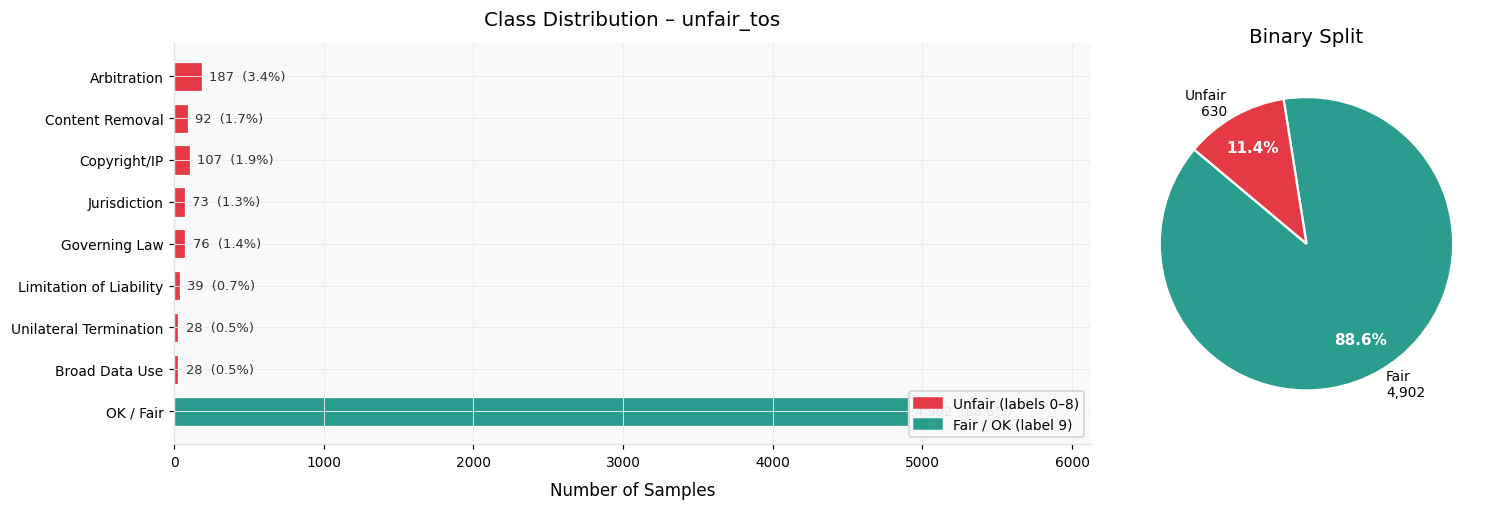

In [8]:
# src/eda_utils.py → plot_class_distribution()
fig = plot_class_distribution(stats)
os.makedirs("../outputs", exist_ok=True)
fig.savefig("../outputs/fig_01_class_distribution.png", bbox_inches="tight", dpi=130)
plt.show()

## 7. Unfair Clause Type Breakdown

Among unfair clauses, **Broad Data Use (use)** and **Limitation of Liability (ltd)** tend to be most frequent.


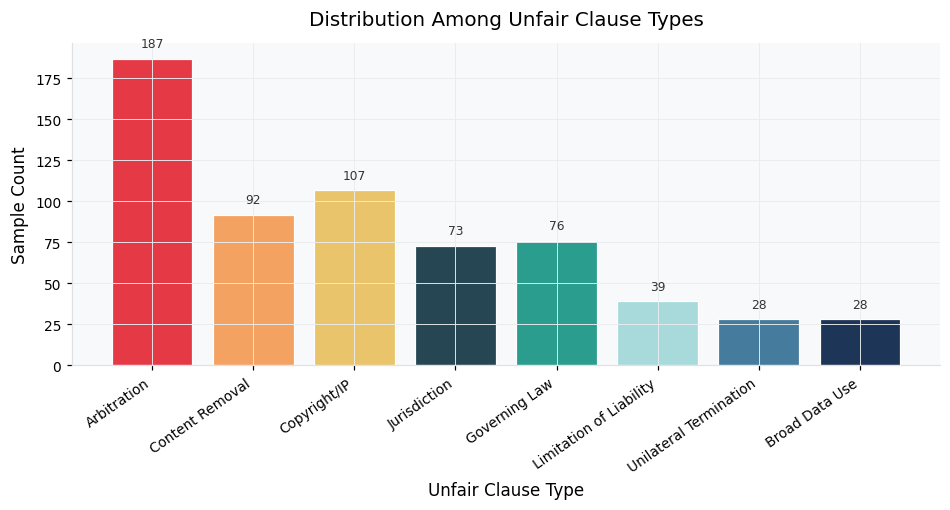

In [9]:
fig = plot_unfair_breakdown(stats)
fig.savefig("../outputs/fig_02_unfair_breakdown.png", bbox_inches="tight", dpi=130)
plt.show()

## 8. Fair vs Unfair Across Splits

Stratification check: the imbalance should be **consistent** across train/val/test.


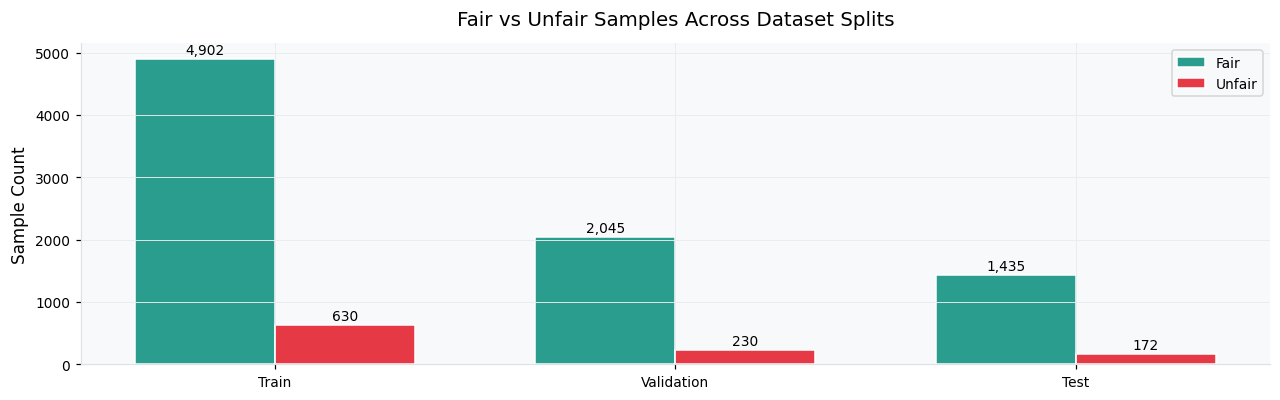

In [10]:
fig = plot_sample_balance_splits(splits)
fig.savefig("../outputs/fig_03_split_balance.png", bbox_inches="tight", dpi=130)
plt.show()

## 9. Imbalance Audit

We quantify the **Imbalance Ratio (IR)** per class:
> IR = majority_count / class_count

A ratio > 10 is considered severe and requires active handling.


In [11]:
ir_global = compute_imbalance_ratio(train_df)
print(f"Global IR (majority / rarest class): {ir_global:.1f}\n")

report = imbalance_report(train_df)
report

Global IR (majority / rarest class): 175.1



,label,label_name,count,pct,IR_vs_majority,strategy
0,0,Arbitration,187,3.38,26.2,Aggressive resampling or synthetic data (SMOTE)
1,1,Content Removal,92,1.66,53.3,Aggressive resampling or synthetic data (SMOTE)
2,2,Copyright/IP,107,1.93,45.8,Aggressive resampling or synthetic data (SMOTE)
3,3,Jurisdiction,73,1.32,67.2,Aggressive resampling or synthetic data (SMOTE)
4,4,Governing Law,76,1.37,64.5,Aggressive resampling or synthetic data (SMOTE)
5,5,Limitation of Liability,39,0.70,125.7,Aggressive resampling or synthetic data (SMOTE)
6,6,Unilateral Termination,28,0.51,175.1,Aggressive resampling or synthetic data (SMOTE)
7,7,Broad Data Use,28,0.51,175.1,Aggressive resampling or synthetic data (SMOTE)
8,9,OK / Fair,4902,88.61,1.0,None needed


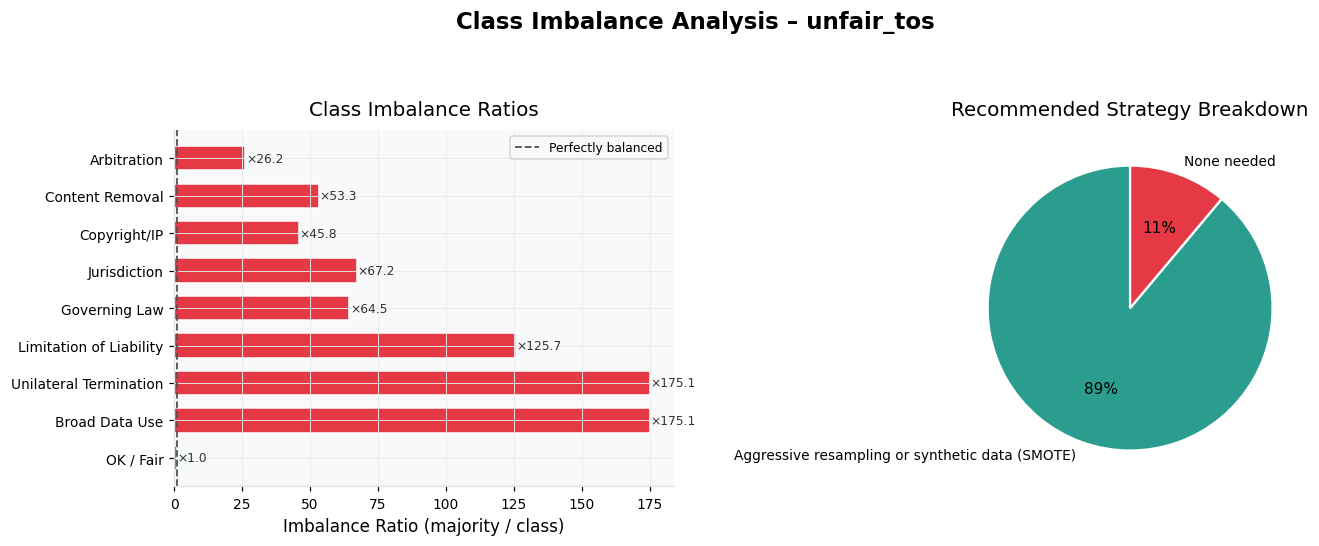

In [12]:
fig = plot_imbalance_summary(report)
fig.savefig("../outputs/fig_04_imbalance_summary.png", bbox_inches="tight", dpi=130)
plt.show()

## 10. Class Weights for Weighted Cross-Entropy

Even after downsampling we will pass `class_weight` to the HuggingFace Trainer.
Two popular formulations:
- **Sklearn balanced**: `n_samples / (n_classes × n_samples_j)`
- **Effective Number of Samples** (Cui et al., CVPR 2019): accounts for feature overlap


In [13]:
class_weights = compute_class_weights_sklearn(train_df)
cw_df = pd.DataFrame([
    {"label": k, "name": LABEL_NAMES[k], "sklearn_weight": v}
    for k, v in class_weights.items()
])

ens = effective_number_of_samples(train_df)
cw_df["ENS_weight"] = cw_df["label"].map(ens.to_dict())
cw_df

,label,name,sklearn_weight,ENS_weight
0,0,Arbitration,3.2870,0.3235
1,1,Content Removal,6.6812,0.6545
2,2,Copyright/IP,5.7445,0.5632
3,3,Jurisdiction,8.4201,0.8241
4,4,Governing Law,8.0877,0.7917
5,5,Limitation of Liability,15.7607,1.5399
6,6,Unilateral Termination,21.9524,2.1437
7,7,Broad Data Use,21.9524,2.1437
8,9,OK / Fair,0.1254,0.0155


## 11. Text-Length Analysis

DistilBERT has a **512-token limit**. If clauses are much longer, we'll need chunking or truncation.


In [14]:
text_stats = compute_text_stats(train_df)
text_stats

text_length                         word_count         \
                               mean median    std min   max       mean median   
label_name                                                                      
Arbitration                   276.2  220.0  234.1  46  1889       50.7   38.0   
Broad Data Use                354.6  292.5  203.2  58   843       62.7   51.0   
Content Removal               199.2  162.0  144.1  46  1191       36.7   28.0   
Copyright/IP                  141.6  128.0   71.5  28   381       26.4   24.0   
Governing Law                 180.5  155.5   95.0  59   553       33.0   28.5   
Jurisdiction                  253.4  215.0  151.1  77   670       46.7   39.0   
Limitation of Liability       222.5  208.0  101.2  44   516       40.5   36.0   
OK / Fair                     173.0  142.0  127.6  15  2535       31.1   26.0   
Unilateral Termination        273.5  254.0  140.0  82   608       49.6   44.5   

                                       sentence_count                      
                          std min  max           mean median  std min max  
label_name                                                                 
Arbitration              44.2   9  353            2.2    2.0  0.7   1   5  
Broad Data Use           37.1   9  153            2.1    2.0  0.4   2   4  
Content Removal          28.7   9  236            2.1    2.0  0.4   2   4  
Copyright/IP             13.3   6   70            2.2    2.0  0.6   2   6  
Governing Law            18.1  12  107            2.1    2.0  0.5   2   5  
Jurisdiction             28.6  14  145            2.1    2.0  0.6   1   6  
Limitation of Liability  18.0  10   95            2.4    2.0  0.8   2   5  
OK / Fair                23.2   6  441            2.1    2.0  0.8   1  10  
Unilateral Termination   27.3  14  116            2.1    2.0  0.4   2   4

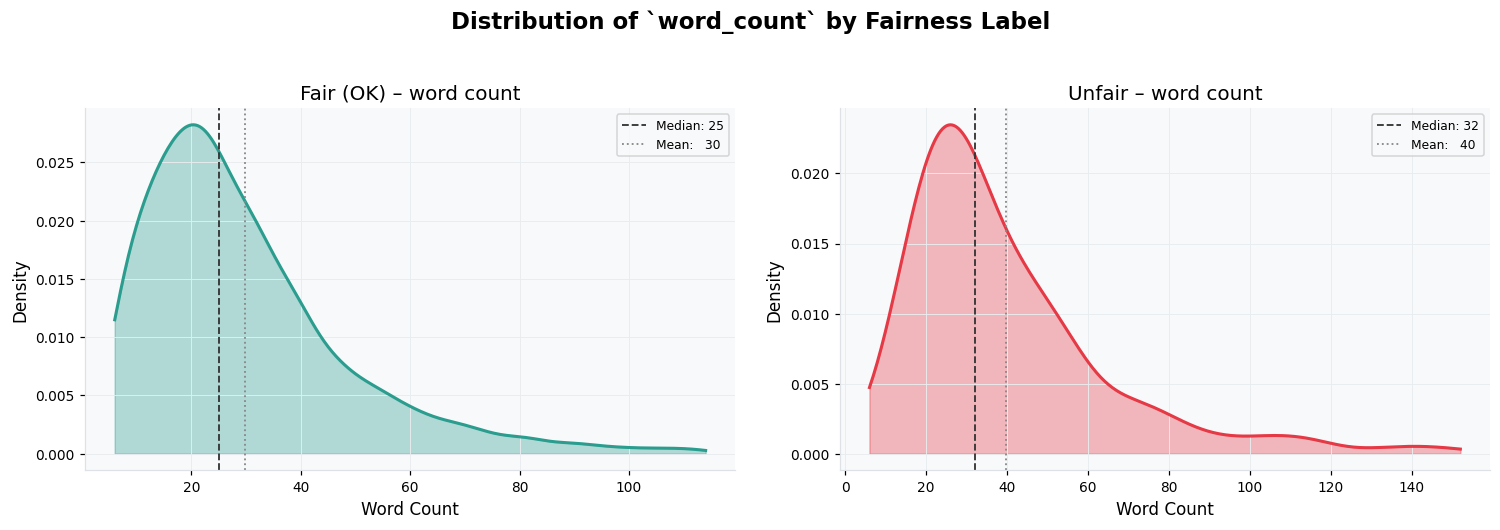

In [15]:
fig = plot_text_length_distribution(train_df, col="word_count")
fig.savefig("../outputs/fig_05_wordcount_dist.png", bbox_inches="tight", dpi=130)
plt.show()

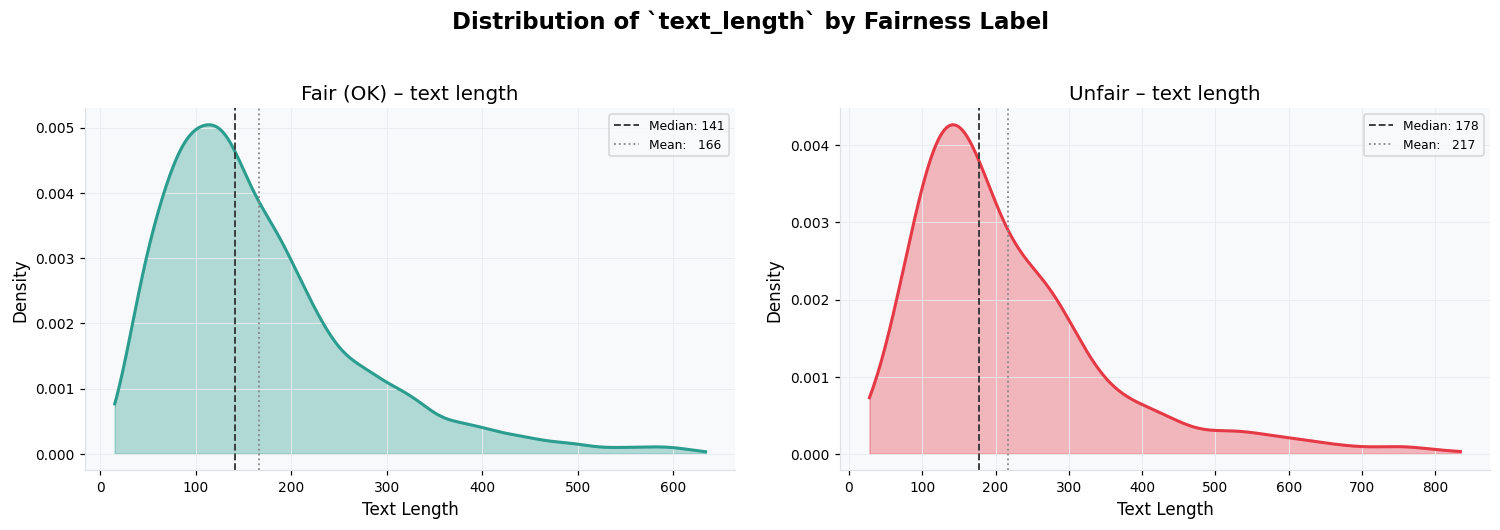

In [16]:
fig = plot_text_length_distribution(train_df, col="text_length")
fig.savefig("../outputs/fig_06_charlength_dist.png", bbox_inches="tight", dpi=130)
plt.show()

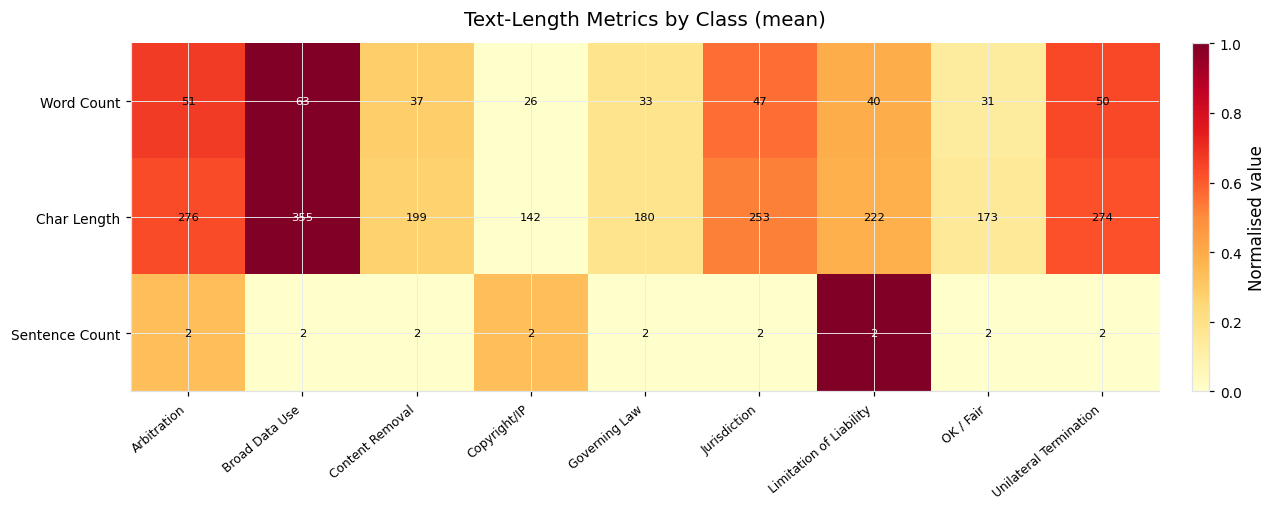

In [17]:
# Per-class heatmap
fig = plot_text_stats_heatmap(train_df)
fig.savefig("../outputs/fig_07_text_stats_heatmap.png", bbox_inches="tight", dpi=130)
plt.show()

## 12. N-gram Vocabulary Analysis

Reveals **linguistic signals** that separate fair from unfair clauses.
Expected patterns:
- Unfair → legalese: *"sole discretion", "without notice", "binding arbitration"*
- Fair    → rights-first language: *"at any time", "notify you", "data protection"*


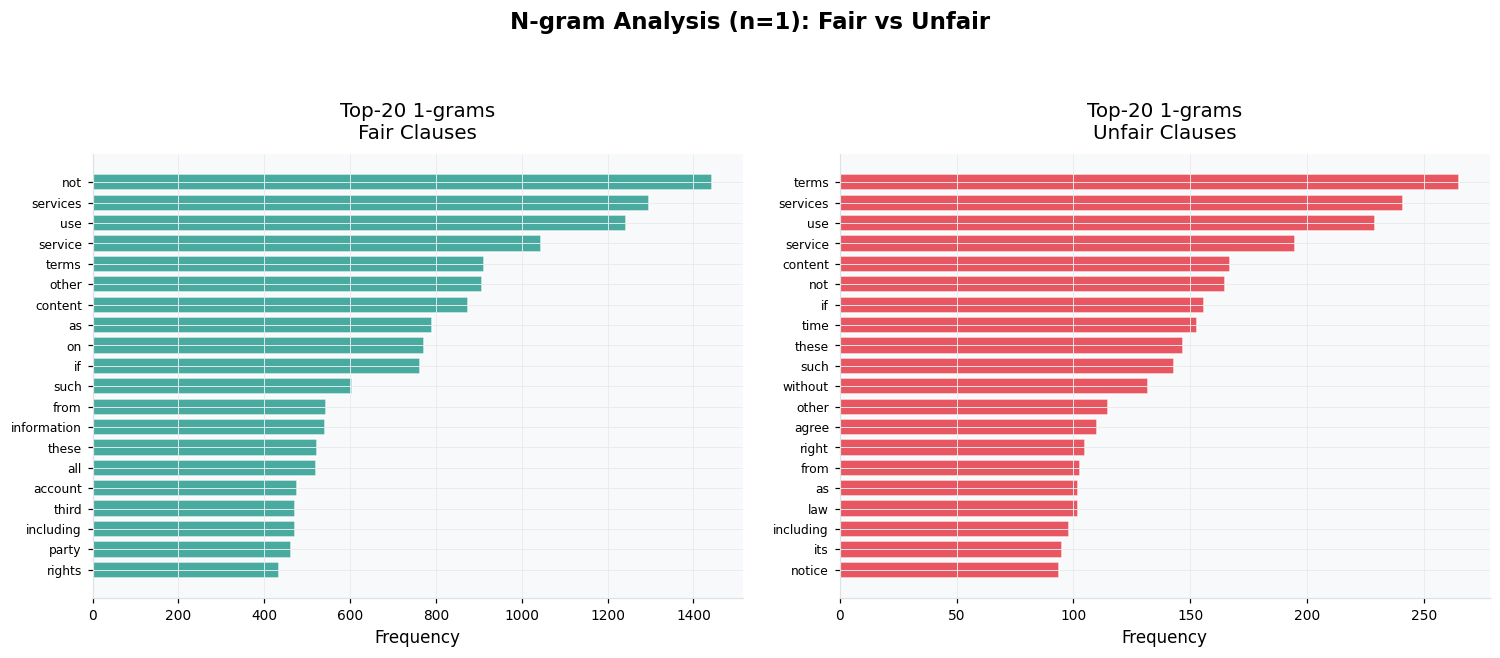

In [18]:
fig = plot_top_ngrams(train_df, n=1, top_k=20)
fig.savefig("../outputs/fig_08_unigrams.png", bbox_inches="tight", dpi=130)
plt.show()

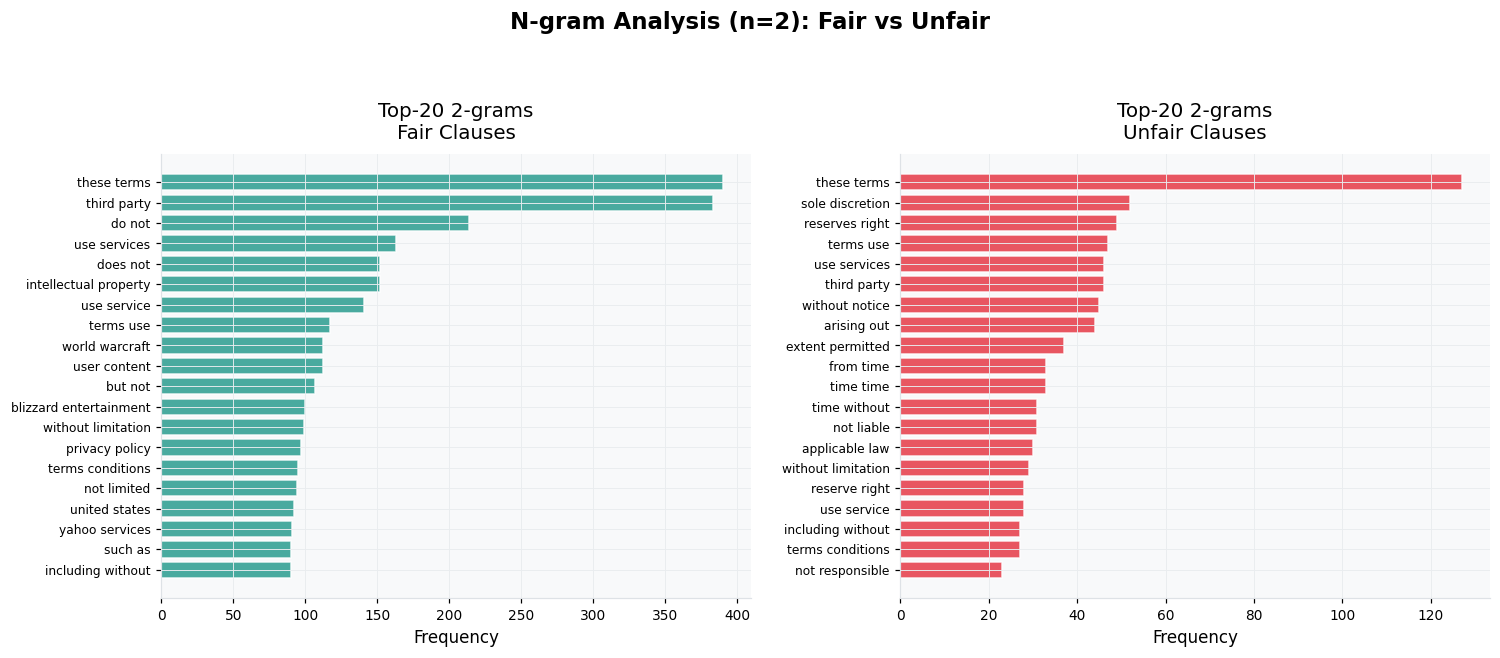

In [19]:
fig = plot_top_ngrams(train_df, n=2, top_k=20)
fig.savefig("../outputs/fig_09_bigrams.png", bbox_inches="tight", dpi=130)
plt.show()

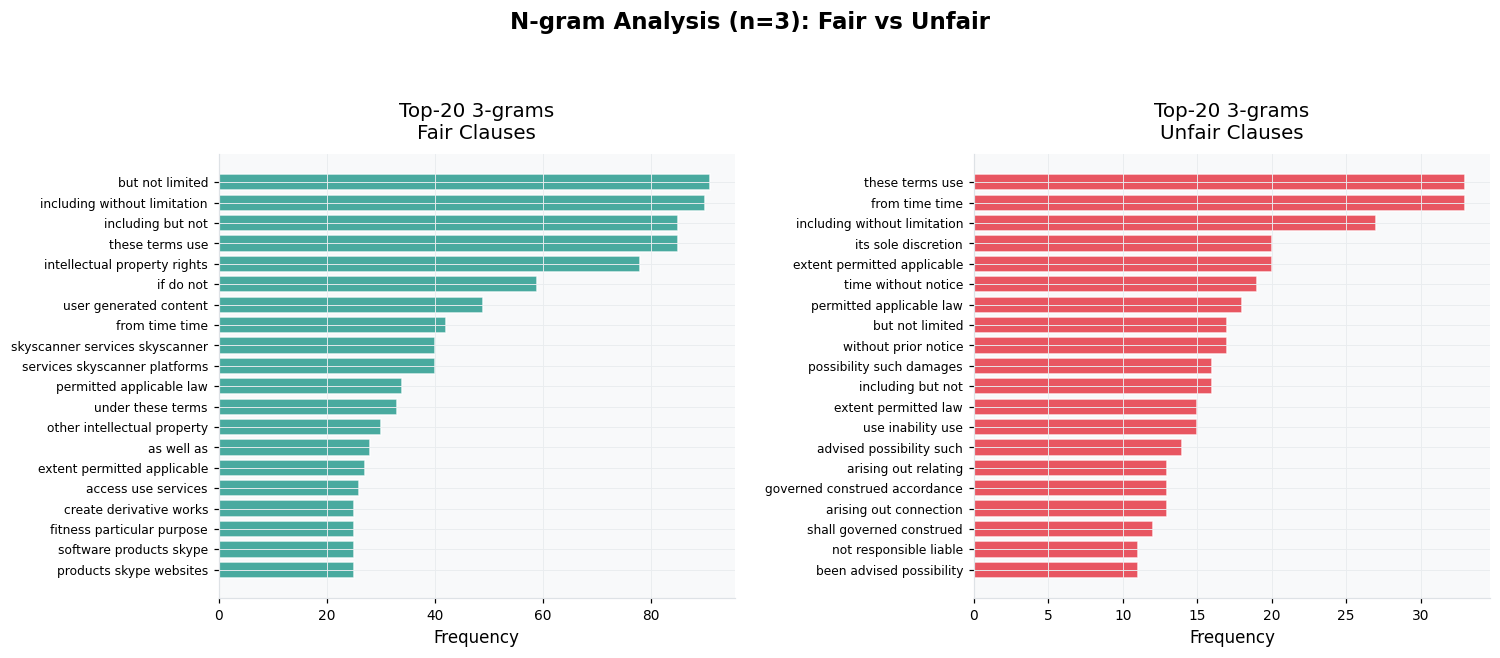

In [20]:
fig = plot_top_ngrams(train_df, n=3, top_k=20)
fig.savefig("../outputs/fig_09_bigrams.png", bbox_inches="tight", dpi=130)
plt.show()

## 13. Resampling Strategy Comparison

We evaluate five strategies and select the one with the best trade-off.

| Strategy | Pros | Cons |
|---|---|---|
| No resampling | Simple | Model learns to always predict Fair |
| Downsample 2:1 | ✅ Keeps all unfair samples, fast training | Drops Fair data |
| Downsample 1:1 | Perfect balance | Drops even more Fair data |
| Oversample 1:1 | No data lost | Overfitting minority, slow |
| Combined | Moderate balance | Complex, may cause leakage |


In [22]:
strat_rows = []
strategies = [
    ("None (original)",  None,          None),
    ("Downsample 2:1",   "downsample",  2.0),
    ("Downsample 1:1",   "downsample",  1.0),
    ("Oversample 1:1",   "oversample",  1.0),
    ("Combined",         "combined",    1.0),
]
for label, strat, ratio in strategies:
    if strat is None:
        fair_n = train_df["is_unfair"].eq(0).sum()
        unf_n  = train_df["is_unfair"].eq(1).sum()
        strat_rows.append({"Strategy": label, "Total": len(train_df),
                           "Fair": fair_n, "Unfair": unf_n,
                           "Fair/Unfair ratio": round(fair_n/max(unf_n,1),2)})
    else:
        _, s = simulate_resampling(train_df, strategy=strat,
                                   target_ratio=ratio, random_state=42)
        strat_rows.append({"Strategy": label, "Total": s["total"],
                           "Fair": s["fair"], "Unfair": s["unfair"],
                           "Fair/Unfair ratio": s["ir_after"]})
pd.DataFrame(strat_rows)

,Strategy,Total,Fair,Unfair,Fair/Unfair ratio
0,None (original),5532,4902,630,7.78
1,Downsample 2:1,1890,1260,630,2.00
2,Downsample 1:1,1260,630,630,1.00
3,Oversample 1:1,9804,4902,4902,1.00
4,Combined,5532,2766,2766,1.00


## 14. Apply Chosen Strategy: Downsample 2:1

**Decision**: Downsample the Fair class to a **2:1 Fair/Unfair ratio**.

Rationale:
- ✅ Retains **100% of scarce unfair samples** — no information loss
- ✅ Reduces training time by ~4× vs the full set
- ✅ Ratio 2:1 retains some majority signal → avoids minority overfitting
- ✅ Residual skew is handled by **class-weighted cross-entropy** in Step 2


Original : 5,532 rows | fair=4,902, unfair=630
Balanced : 1,890 rows | fair=1,260, unfair=630


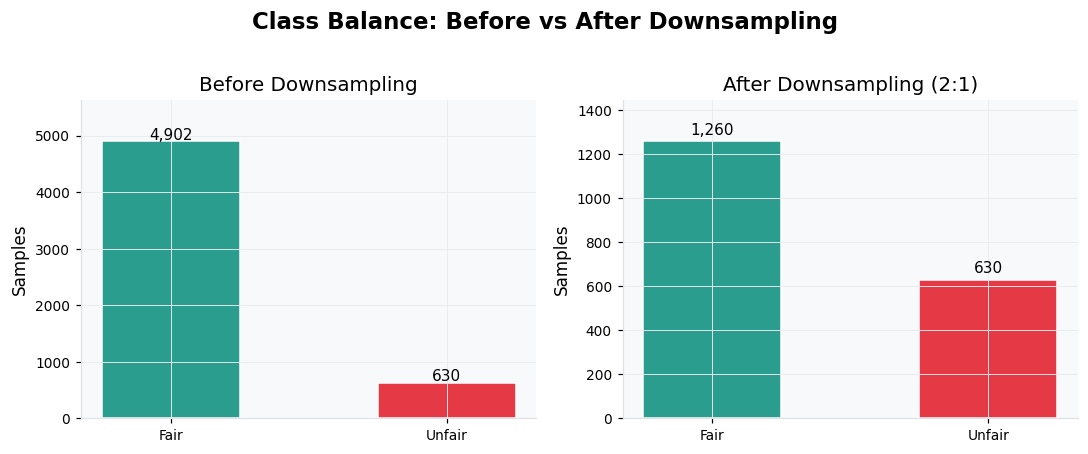

In [23]:
train_balanced = downsample_majority_class(train_df, target_ratio=2.0, random_state=42)

print(f"Original : {len(train_df):,} rows | "
      f"fair={train_df['is_unfair'].eq(0).sum():,}, "
      f"unfair={train_df['is_unfair'].eq(1).sum():,}")
print(f"Balanced : {len(train_balanced):,} rows | "
      f"fair={train_balanced['is_unfair'].eq(0).sum():,}, "
      f"unfair={train_balanced['is_unfair'].eq(1).sum():,}")

# Before/after visual
set_style()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, df_plot, title in [
    (axes[0], train_df,       "Before Downsampling"),
    (axes[1], train_balanced, "After Downsampling (2:1)"),
]:
    cnts   = df_plot["is_unfair"].value_counts().sort_index()
    colors = [PALETTE_FAIR, PALETTE_UNFAIR]
    ax.bar(["Fair", "Unfair"], cnts.values, color=colors,
           edgecolor="white", width=0.5)
    for i, v in enumerate(cnts.values):
        ax.text(i, v + 30, f"{v:,}", ha="center", fontsize=10)
    ax.set_ylabel("Samples")
    ax.set_title(title)
    ax.set_ylim(0, max(cnts.values) * 1.15)
fig.suptitle("Class Balance: Before vs After Downsampling", y=1.02)
plt.tight_layout()
fig.savefig("../outputs/fig_10_resampling_comparison.png", bbox_inches="tight", dpi=130)
plt.show()

## 15. Sample Inspection

One example per unfair clause type — useful for sanity checking the labels.


In [24]:
pd.set_option("display.max_colwidth", 300)

sample_rows = []
for lbl in sorted(UNFAIR_LABELS):
    subset = train_df[train_df["label"] == lbl]
    if len(subset) == 0:
        continue
    row = subset.sample(1, random_state=42).iloc[0]
    sample_rows.append({
        "ID": lbl,
        "Type": LABEL_NAMES[lbl],
        "Sample Text": row["text"][:280] + ("…" if len(row["text"]) > 280 else ""),
        "Words": row["word_count"],
    })
pd.DataFrame(sample_rows)

,ID,Type,Sample Text,Words
0,0,Arbitration,"to the maximum extent permitted by law , we ( together with our officers , directors , employees , representatives , affiliates , providers and third parties ) do not accept any liability for ( a ) any inaccuracies or omissions in the content displayed on or via the skyscanner se…",152
1,1,Content Removal,"if we reasonably suspect that your microsoft account or skype account is being used by a third party fraudulently ( for example , as a result of an account compromise ) , microsoft may suspend your account until you can reclaim ownership . \n",43
2,2,Copyright/IP,we reserve the right to change this user agreement from time to time without notice . \n,16
3,3,Jurisdiction,"while we do not and can not review every message or other material posted or sent by users of the service , and are not responsible for any content of these messages or materials , we reserve the right , but are not obligated , to delete , move , or edit messages or materials , i…",97
4,4,Governing Law,when you ( `` you '' ) sign up with betterpoints.uk you agree to all of the terms and conditions of this agreement ( `` agreement '' ) . \n,29
5,5,Limitation of Liability,"apart from that , if you are united states resident , these terms and our relationship will be governed by california law , except for its conflicts of laws principles . \n",31
6,6,Unilateral Termination,"for any action at law or in equity relating to the arbitration provision of these terms of use , the excluded disputes or if you opt out of the agreement to arbitrate , you agree to resolve any dispute you have with instagram exclusively in a state or federal court located in san…",81
7,7,Broad Data Use,"the arbitration shall be conducted in helsinki , finland , in the english language . \n",15


## 16. Export Artefacts

All outputs written to `outputs/` and consumed by the next notebook (`02_finetune_distilbert.ipynb`).


In [25]:
os.makedirs("../outputs", exist_ok=True)

# Parquet splits (efficient columnar format)
train_balanced.to_csv("../outputs/train_balanced.csv", index=False)
val_df.to_csv("../outputs/val.csv",                    index=False)
test_df.to_csv("../outputs/test.csv",                  index=False)

# CSVs for readability / auditing
label_schema = pd.DataFrame([
    {"ID": k, "Abbreviation": LABEL_ABBR[k],
     "Full Name": LABEL_NAMES[k],
     "Is Unfair": k in UNFAIR_LABELS}
    for k in LABEL_NAMES
])
label_schema.to_csv("../outputs/label_schema.csv",      index=False)
report.to_csv("../outputs/imbalance_report.csv",        index=False)
cw_df.to_csv("../outputs/class_weights.csv",            index=False)

print("✅ EDA complete. Artefacts saved to outputs/:")
print("")
for f in sorted(os.listdir("../outputs")):
    size = os.path.getsize(f"../outputs/{f}")
    print(f"  {f:45s}  {size//1024:>4} KB")

print("\n🔜 Next: notebooks/02_finetune_distilbert.ipynb")

✅ EDA complete. Artefacts saved to outputs/:

  class_weights.csv                                 0 KB
  fig_01_class_distribution.png                    87 KB
  fig_02_unfair_breakdown.png                      62 KB
  fig_03_split_balance.png                         35 KB
  fig_04_imbalance_summary.png                     93 KB
  fig_05_wordcount_dist.png                        91 KB
  fig_06_charlength_dist.png                       93 KB
  fig_07_text_stats_heatmap.png                    72 KB
  fig_08_unigrams.png                              73 KB
  fig_09_bigrams.png                              135 KB
  fig_10_resampling_comparison.png                 47 KB
  imbalance_report.csv                              0 KB
  label_schema.csv                                  0 KB
  test.csv                                        327 KB
  train_balanced.csv                              408 KB
  val.csv                                         486 KB

🔜 Next: notebooks/02_finetune_distilbert.